In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split
import seaborn as sns 
import configparser

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
vf = pd.read_csv(r'C:\Users\isaac\Documents\GitHub\NavalVesselPerformance\navy_vessel\vessel\data.csv')

In [ ]:
vf.head()

,index,Lever position,Ship speed (v),Gas Turbine (GT) shaft torque (GTT) [kN m],GT rate of revolutions (GTn) [rpm],Gas Generator rate of revolutions (GGn) [rpm],Starboard Propeller Torque (Ts) [kN],Port Propeller Torque (Tp) [kN],Hight Pressure (HP) Turbine exit temperature (T48) [C],GT Compressor inlet air temperature (T1) [C],GT Compressor outlet air temperature (T2) [C],HP Turbine exit pressure (P48) [bar],GT Compressor inlet air pressure (P1) [bar],GT Compressor outlet air pressure (P2) [bar],GT exhaust gas pressure (Pexh) [bar],Turbine Injecton Control (TIC) [%],Fuel flow (mf) [kg/s],GT Compressor decay state coefficient,GT Turbine decay state coefficient
0,0,1.138,3,289.964,1349.489,6677.380,7.584,7.584,464.006,288,550.563,1.096,0.998,5.947,1.019,7.137,0.082,0.95,0.975
1,1,2.088,6,6960.180,1376.166,6828.469,28.204,28.204,635.401,288,581.658,1.331,0.998,7.282,1.019,10.655,0.287,0.95,0.975
2,2,3.144,9,8379.229,1386.757,7111.811,60.358,60.358,606.002,288,587.587,1.389,0.998,7.574,1.020,13.086,0.259,0.95,0.975
3,3,4.161,12,14724.395,1547.465,7792.630,113.774,113.774,661.471,288,613.851,1.658,0.998,9.007,1.022,18.109,0.358,0.95,0.975
4,4,5.140,15,21636.432,1924.313,8494.777,175.306,175.306,731.494,288,645.642,2.078,0.998,11.197,1.026,26.373,0.522,0.95,0.975


## Data Manipulation 

In [4]:
# Feature handling

vf.drop(columns="index", inplace=True)

# Missing values

print(f"Missing Values in Vessels:\n{vf.isnull().sum()}") 

# Duplicate values 

print(f"Number of duplicates:{vf.duplicated().sum()}")



Missing Values in Vessels:
Lever position                                              0
Ship speed (v)                                              0
Gas Turbine (GT) shaft torque (GTT) [kN m]                  0
GT rate of revolutions (GTn) [rpm]                          0
Gas Generator rate of revolutions (GGn) [rpm]               0
Starboard Propeller Torque (Ts) [kN]                        0
Port Propeller Torque (Tp) [kN]                             0
Hight Pressure (HP) Turbine exit temperature (T48) [C]      0
GT Compressor inlet air temperature (T1) [C]                0
GT Compressor outlet air temperature (T2) [C]               0
HP Turbine exit pressure (P48) [bar]                        0
GT Compressor inlet air pressure (P1) [bar]                 0
GT Compressor outlet air pressure (P2) [bar]                0
GT exhaust gas pressure (Pexh) [bar]                        0
Turbine Injecton Control (TIC) [%]                          0
Fuel flow (mf) [kg/s]                      

In [5]:
# Outlier Detection 

Q1 = np.percentile(vf,25)
Q3 = np.percentile(vf, 75)

iqr = Q3 - Q1 

lower= Q1 - 1.5*iqr 
upper= Q3 + 1.5*iqr

cols = list(vf.columns)

outliers = {}
for col in cols: 
    outliers[col] = vf[(vf[col] > upper) | (vf[col] < lower)].sum()
    print(f"{outliers}")

{'Lever position ': Lever position                                              0.0
Ship speed (v)                                              0.0
Gas Turbine (GT) shaft torque (GTT) [kN m]                  0.0
GT rate of revolutions (GTn) [rpm]                          0.0
Gas Generator rate of revolutions (GGn) [rpm]               0.0
Starboard Propeller Torque (Ts) [kN]                        0.0
Port Propeller Torque (Tp) [kN]                             0.0
Hight Pressure (HP) Turbine exit temperature (T48) [C]      0.0
GT Compressor inlet air temperature (T1) [C]                0.0
GT Compressor outlet air temperature (T2) [C]               0.0
HP Turbine exit pressure (P48) [bar]                        0.0
GT Compressor inlet air pressure (P1) [bar]                 0.0
GT Compressor outlet air pressure (P2) [bar]                0.0
GT exhaust gas pressure (Pexh) [bar]                        0.0
Turbine Injecton Control (TIC) [%]                          0.0
Fuel flow (mf) [kg/s

Text(0.5, 1.0, 'Outlier Visual')

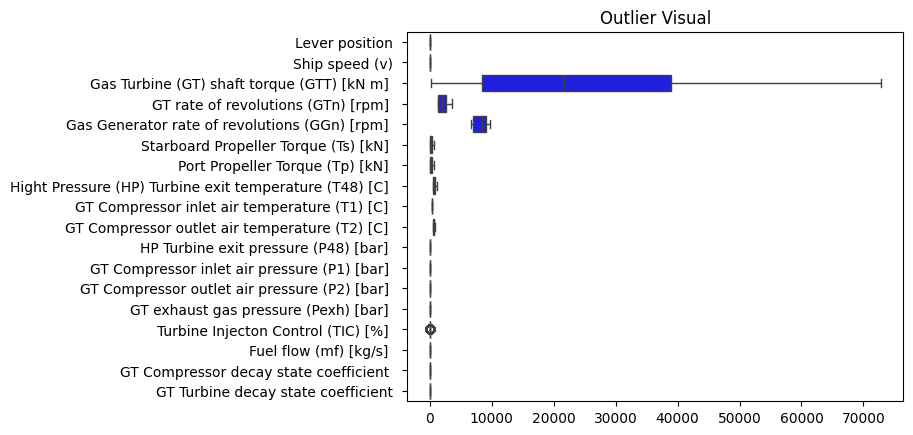

In [6]:
sns.boxplot(vf,orient="h", color="blue")
plt.title("Outlier Visual")

In [7]:
from janitor import clean_names

vf = clean_names(vf)
vf.head()

,lever_position_,ship_speed_v_,gas_turbine_gt_shaft_torque_gtt_[kn_m]_,gt_rate_of_revolutions_gtn_[rpm]_,gas_generator_rate_of_revolutions_ggn_[rpm]_,starboard_propeller_torque_ts_[kn]_,port_propeller_torque_tp_[kn]_,hight_pressure_hp_turbine_exit_temperature_t48_[c]_,gt_compressor_inlet_air_temperature_t1_[c]_,gt_compressor_outlet_air_temperature_t2_[c]_,hp_turbine_exit_pressure_p48_[bar]_,gt_compressor_inlet_air_pressure_p1_[bar]_,gt_compressor_outlet_air_pressure_p2_[bar]_,gt_exhaust_gas_pressure_pexh_[bar]_,turbine_injecton_control_tic_[%]_,fuel_flow_mf_[kg_s]_,gt_compressor_decay_state_coefficient_,gt_turbine_decay_state_coefficient_
0,1.138,3,289.964,1349.489,6677.380,7.584,7.584,464.006,288,550.563,1.096,0.998,5.947,1.019,7.137,0.082,0.95,0.975
1,2.088,6,6960.180,1376.166,6828.469,28.204,28.204,635.401,288,581.658,1.331,0.998,7.282,1.019,10.655,0.287,0.95,0.975
2,3.144,9,8379.229,1386.757,7111.811,60.358,60.358,606.002,288,587.587,1.389,0.998,7.574,1.020,13.086,0.259,0.95,0.975
3,4.161,12,14724.395,1547.465,7792.630,113.774,113.774,661.471,288,613.851,1.658,0.998,9.007,1.022,18.109,0.358,0.95,0.975
4,5.140,15,21636.432,1924.313,8494.777,175.306,175.306,731.494,288,645.642,2.078,0.998,11.197,1.026,26.373,0.522,0.95,0.975


### Feature Creation and Selection

In [8]:
vf["v_ms"] = vf["ship_speed_v_"] * 0.5144
vf["Velocity_mf"] = vf["v_ms"] / vf["fuel_flow_mf_[kg_s]_"]

X = vf.drop("Velocity_mf", axis = 1)
y = vf["Velocity_mf"]

In [9]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X,y)
mi_mask = mi_scores > 0.05
X_fil = X.loc[:,mi_mask]

# Multicollinearity filter

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_fil = add_constant(X_fil)
def compute_vif(X): 
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) 
                  for i in range(X.shape[1])]
    return vif.sort_values('VIF', ascending=False)

vif = compute_vif(X_fil)
vif # High VIF, use Ridge Regression

c:\Users\isaac\Documents\Personal_Projects\AI\navy_vessel\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,features,VIF
2,ship_speed_v_,inf
7,port_propeller_torque_tp_[kn]_,inf
6,starboard_propeller_torque_ts_[kn]_,inf
16,v_ms,inf
0,const,1.233207e+07
1,lever_position_,4.226545e+04
3,gas_turbine_gt_shaft_torque_gtt_[kn_m]_,3.771820e+04
10,hp_turbine_exit_pressure_p48_[bar]_,3.326802e+04
11,gt_compressor_outlet_air_pressure_p2_[bar]_,2.251765e+04
14,fuel_flow_mf_[kg_s]_,1.786492e+04


<Axes: >

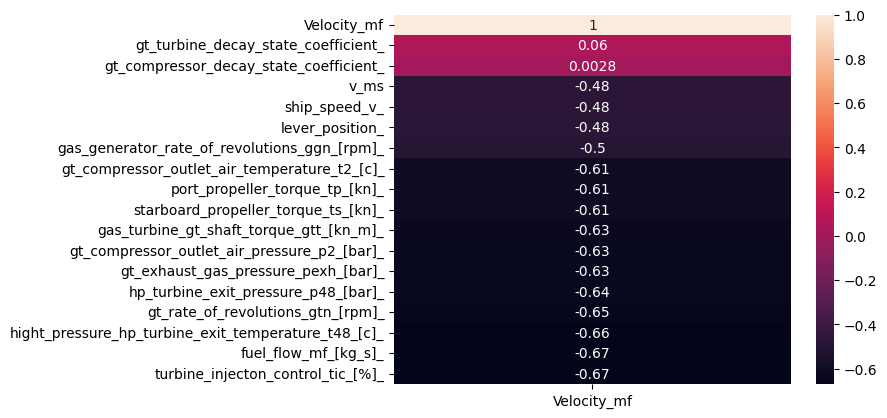

In [10]:
# Correlations

df1 = vf.drop(columns = ["gt_compressor_inlet_air_temperature_t1_[c]_", "gt_compressor_inlet_air_pressure_p1_[bar]_"])
corr_matrix = df1.corr()
sns.heatmap(corr_matrix[['Velocity_mf']].sort_values(by='Velocity_mf', ascending=False), annot=True)

In [11]:
# use VIF and correlation to select possible features 
df1.rename({"hight_pressure_hp_turbine_exit_temperature_t48_": "height_pressure_hp_turbine_exit_temp"}, inplace=True)
X = df1[["turbine_injecton_control_tic_[%]_", "hight_pressure_hp_turbine_exit_temperature_t48_[c]_","gt_rate_of_revolutions_gtn_[rpm]_", "lever_position_"]]
y = df1["Velocity_mf"]

In [12]:
df_fin = pd.concat([X, y.to_frame()], axis=1)

### EDA ###

In [ ]:
df_fin.head()

fig, ax = plt.subplots(1,3)

plt.subplot(1,3,1)


,turbine_injecton_control_tic_[%]_,hight_pressure_hp_turbine_exit_temperature_t48_[c]_,gt_rate_of_revolutions_gtn_[rpm]_,lever_position_,Velocity_mf
0,7.137,464.006,1349.489,1.138,18.819512
1,10.655,635.401,1376.166,2.088,10.754007
2,13.086,606.002,1386.757,3.144,17.874903
3,18.109,661.471,1547.465,4.161,17.242458
4,26.373,731.494,1924.313,5.140,14.781609


### Modeling ###

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

In [15]:
compute_vif(df_fin)

,features,VIF
2,gt_rate_of_revolutions_gtn_[rpm]_,306.624912
1,hight_pressure_hp_turbine_exit_temperature_t48...,216.724584
3,lever_position_,57.820836
0,turbine_injecton_control_tic_[%]_,35.371929
4,Velocity_mf,17.846920


In [17]:
# Train-test-split
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [18]:
scaler = StandardScaler() 
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [20]:
ridge = Ridge(alpha=1.0) 
ridge.fit(x_train_scaled, y_train)
y_pred = ridge.predict(x_test_scaled)

In [21]:
from sklearn.metrics import root_mean_squared_error, r2_score

In [22]:
print(f"RSME: {root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score: {r2_score(y_test, y_pred)}")

RSME: 1.7667259041530765
r2 score: 0.8197245444090336


In [23]:
from sklearn.model_selection import KFold, cross_val_score

In [24]:
# Test Model Assumptions (i.e Linearity, Predictor Independence, Homeoscedasticity)

In [ ]:
# fitted and residuals for training data

import statsmodels
train_pred = ridge.predict(x_train_scaled)
train_residuals = y_train - train_pred

train_df = pd.DataFrame({
    "Actual": y_train,
    "Fitted": train_pred,
    "Residuals": train_residuals

})



In [26]:
""" 
2. Normality check of residuals

""" 
from scipy.stats import shapiro
norm_value = shapiro(train_residuals)
print(f"Shapiro-test value: {norm_value.statistic}")
print(f"Shapiro-test p-value: {norm_value.pvalue}")

Shapiro-test value: 0.9400553757349823
Shapiro-test p-value: 5.1763713649154576e-52


c:\Users\isaac\Documents\Personal_Projects\AI\navy_vessel\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9547.
  res = hypotest_fun_out(*samples, **kwds)


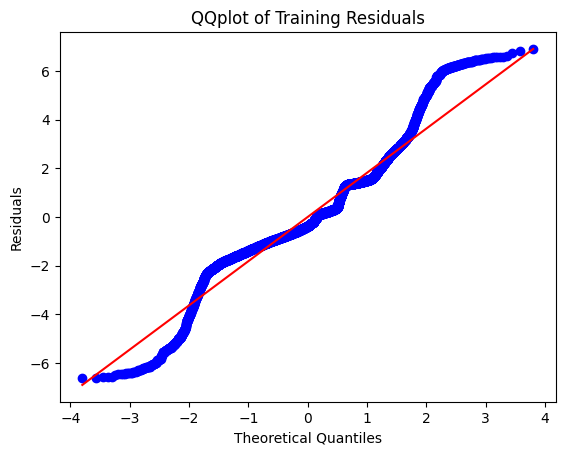

In [27]:
from scipy.stats import probplot

probplot(train_residuals, dist="norm", plot=plt)
plt.title("QQplot of Training Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Residuals")
plt.show()

In [26]:
# The model appears to be non-linear in nature. The curve does not follow along the qqplot line and it fails the Shapiro Test. 

In [28]:
from scipy.stats import boxcox, boxcox_normplot

(array([ 72.,  72.,  70.,  75.,  68.,  63.,  76., 681., 752.,  58.,  41.,
         31.,  48., 566., 821.,  57.,  80., 149., 646., 748., 165., 591.,
        686., 204.,  73., 302., 609., 485., 156.,  46.,  72., 214., 462.,
        640., 580., 495., 300., 203.,  86.,  27.,  35.,  50.,  40.,  32.,
         52.,  52.,  55.,  35.,  10.,   3.]),
 array([ 4.56568047,  4.97622052,  5.38676057,  5.79730062,  6.20784067,
         6.61838072,  7.02892077,  7.43946082,  7.85000087,  8.26054091,
         8.67108096,  9.08162101,  9.49216106,  9.90270111, 10.31324116,
        10.72378121, 11.13432126, 11.54486131, 11.95540136, 12.36594141,
        12.77648145, 13.1870215 , 13.59756155, 14.0081016 , 14.41864165,
        14.8291817 , 15.23972175, 15.6502618 , 16.06080185, 16.4713419 ,
        16.88188195, 17.29242199, 17.70296204, 18.11350209, 18.52404214,
        18.93458219, 19.34512224, 19.75566229, 20.16620234, 20.57674239,
        20.98728244, 21.39782249, 21.80836253, 22.21890258, 22.62944263,
 

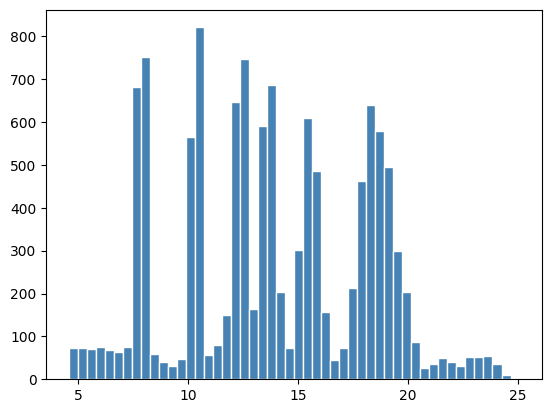

In [31]:
plt.hist(y, bins = 50, color="steelblue", edgecolor="white")

In [32]:
from scipy.stats import boxcox

In [33]:
transformed_y, best_lambda = boxcox(y)

In [34]:
print(f"Optimal lambda:{best_lambda:.4f}")

Optimal lambda:0.8261


(array([ 60.,  68.,  50.,  65.,  61.,  62.,  60.,  70., 479., 945.,  51.,
         46.,  30.,  34., 100., 998., 346.,  52.,  90., 247., 814., 530.,
        200., 698., 565., 120., 115., 443., 637., 346.,  85.,  56., 123.,
        389., 650., 681., 501., 342., 248.,  86.,  38.,  44.,  41.,  45.,
         34.,  56.,  64.,  56.,  10.,   3.]),
 array([ 3.03345961,  3.2954144 ,  3.55736919,  3.81932398,  4.08127877,
         4.34323356,  4.60518835,  4.86714314,  5.12909793,  5.39105272,
         5.65300751,  5.9149623 ,  6.17691709,  6.43887188,  6.70082667,
         6.96278146,  7.22473625,  7.48669104,  7.74864583,  8.01060062,
         8.27255541,  8.5345102 ,  8.79646498,  9.05841977,  9.32037456,
         9.58232935,  9.84428414, 10.10623893, 10.36819372, 10.63014851,
        10.8921033 , 11.15405809, 11.41601288, 11.67796767, 11.93992246,
        12.20187725, 12.46383204, 12.72578683, 12.98774162, 13.24969641,
        13.5116512 , 13.77360599, 14.03556078, 14.29751557, 14.55947036,
 

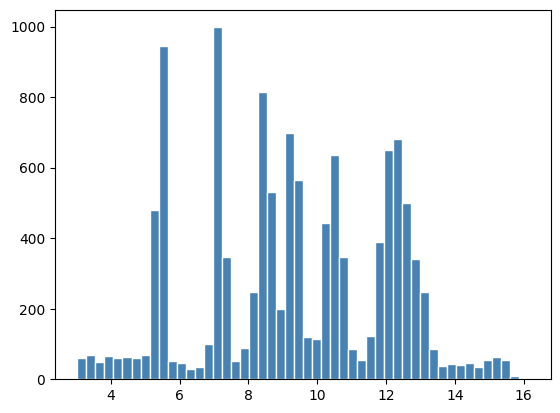

In [35]:
plt.hist(transformed_y, color="steelblue", bins=50, edgecolor="white")

In [34]:
# The tranformed outcome variable appears to be more normal 

In [36]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(X,transformed_y, test_size=0.2, random_state=42)

In [37]:
x_train1_scaled = scaler.fit_transform(x_train1)
x_test1_scaled = scaler.transform(x_test1)

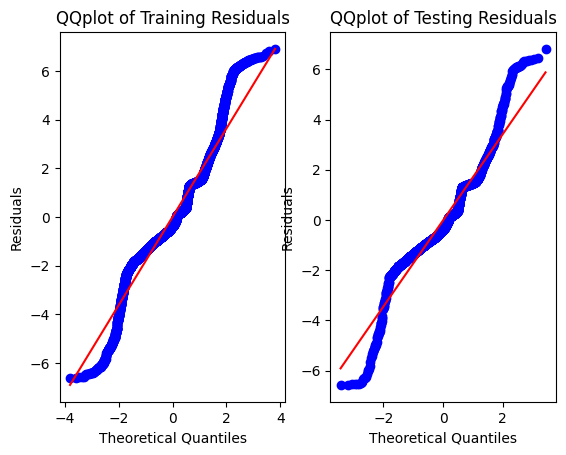

In [89]:
train_pred1 = ridge.predict(x_train1_scaled)
train_residuals1 = y_train1 - train_pred1

test_pred1 = ridge.predict(x_test1_scaled)
test_residuals1 = y_test1 - test_pred1

train_df1 = pd.DataFrame({
    "Actual": y_train1,
    "Fitted": train_pred1,
    "Residuals": train_residuals1

})

plt.subplot(1, 2, 1)
probplot(train_residuals1, dist="norm", plot=plt)
plt.title("QQplot of Training Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Residuals")

plt.subplot(1, 2, 2)
probplot(test_residuals1, dist="norm", plot=plt)
plt.title("QQplot of Testing Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Residuals")
plt.show() 

In [39]:
test, p = shapiro(train_residuals1)
print("test:", test)
print("p-value:", p)

test: 0.8809652507286816
p-value: 7.631761782297207e-65


c:\Users\isaac\Documents\Personal_Projects\AI\navy_vessel\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9547.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
""" 
Addressing issue: 

-Non parametric testing
-Ridge alpha tuning * 
-Recursive Feature Elimination *
"""

' \nAddressing issue: \n\n-Non parametric testing\n-Ridge alpha tuning \n-Recursive Feature Elimination\n'

In [42]:
# Revamped Ridge model (S: Recursive Feature Elimination + Ridge + CV)


from sklearn.feature_selection import RFECV 
from sklearn.linear_model import Ridge 
from sklearn.model_selection import KFold

cv = KFold(n_splits = 5, shuffle=True, random_state=42)
x_train1, x_test1, y_train1, y_test1 = train_test_split(X,y, test_size=0.2, random_state=42)

selector = RFECV(
    Ridge(alpha=1.0),
    step=1,
    cv=cv,
    scoring= "neg_mean_squared_error"
)

y_transformed, best_lambda = boxcox(y_train1)
selector.fit(x_train1, y_transformed)
print(f"Optimal number of features: {selector.n_features_}")
X_train_rfe = selector.transform(x_train1)
print(f"Best Features: {list(x_train1.columns)}")

Optimal number of features: 4
Best Features: ['turbine_injecton_control_tic_[%]_', 'hight_pressure_hp_turbine_exit_temperature_t48_[c]_', 'gt_rate_of_revolutions_gtn_[rpm]_', 'lever_position_']


In [43]:
from sklearn.model_selection import cross_val_score

In [44]:
ridge_vamp = Ridge(alpha=1.0)

scores = cross_val_score(ridge_vamp, X_train_rfe, y_transformed, cv = cv)
print(f"R2 scores:{scores}")
print(f"Mean: {scores.mean(): .4f}")
print(f"Std: {scores.std(): .4f}") # Good std

R2 scores:[0.8292693  0.83125362 0.81707107 0.81748732 0.81193827]
Mean:  0.8214
Std:  0.0075


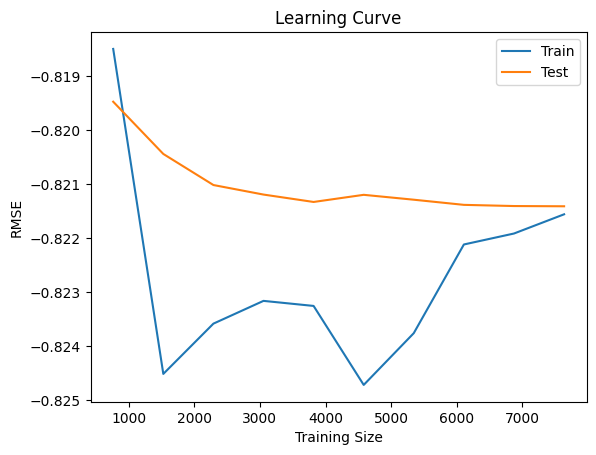

In [45]:
# Model Evaluation (Check for Overfitting vs. Underfitting)

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    ridge_vamp, X_train_rfe, y_transformed, 
    cv = cv,
    train_sizes = np.linspace(0.1,1.0, 10)
)

plt.plot(train_sizes, -train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Test')
plt.xlabel("Training Size")
plt.ylabel("RMSE")
plt.legend()
plt.title("Learning Curve")
plt.show()

In [48]:
# There is minimal separation between the training and testing curves. Ideal learning curve for the model.

In [52]:
# Feature Importance 

from sklearn.inspection import permutation_importance

result = permutation_importance(ridge_vamp.fit(X_train_rfe, y_transformed), X_train_rfe, y_transformed, n_repeats=10, random_state=42)

# Create DataFrame
perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_importance_df)

                                             Feature  Importance
3                                    lever_position_   13.485196
1  hight_pressure_hp_turbine_exit_temperature_t48...   11.840071
2                  gt_rate_of_revolutions_gtn_[rpm]_    3.457352
0                  turbine_injecton_control_tic_[%]_    0.689976


### Full Pipeline Ridge ###

In [82]:
from sklearn.linear_model import Ridge
from scipy.special import inv_boxcox

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ("Scaling:", StandardScaler()), 
    ("Selector:", RFECV(
    estimator=RidgeCV(alphas=np.logspace(0.1,1,10)),
    step=1,
    cv=5,
    scoring= "neg_mean_squared_error"
)), ("Model:", RidgeCV(alphas=np.logspace(0.1,1,10), cv = 5, scoring='neg_mean_squared_error')),
])

y_transformed, lambda_val = boxcox(y_train)
pipeline.fit(x_train, y_transformed)

y_pred_trans = pipeline.predict(x_test)
y_pred = inv_boxcox(y_pred_trans, lambda_val)

In [84]:
# Evaluate Model 

from sklearn.metrics import r2_score, root_mean_squared_error
print(f"Model r2 score: {r2_score(y_test, y_pred)}") 

# training and testing rsme 

train_pred = pipeline.predict(x_train)
print(f"Testing RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"Training RMSE: {root_mean_squared_error(y_train, train_pred)}")

print(y_test.std(), y_train.std())

# training and testing mae 

from sklearn.metrics import mean_absolute_error
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

Model r2 score: 0.8320021156999098
Testing RMSE: 1.7055041563771765
Training RMSE: 5.242331612898839
4.1619021539487635 4.285344146036785
Train MAE: 1.381778868204152
Test MAE: 1.2578337477957398


In [105]:
# Dump the model 

import pickle
import joblib

pickle.dump(pipeline, open("Pipeline.pkl", 'wb'))

pickled_model = joblib.load('Pipeline.pkl')

new_data = pd.DataFrame({
    
    'gt_rate_of_revolutions_gtn_[rpm]_': [1400],
    'hight_pressure_hp_turbine_exit_temperature_t48_[c]_': [500],
    'turbine_injecton_control_tic_[%]_': [20],
    'lever_position_': [4],
    
}) 

ynew = pickled_model.predict(new_data)

ValueError: The feature names should match those that were passed during fit.
Feature names must be in the same order as they were in fit.


### Streamlit ###

In [37]:
import streamlit as st 

In [53]:
st.title("Naval Vessel Performance")

2026-06-20 20:39:58.977 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 20:39:59.623 
  command:

    streamlit run c:\Users\isaac\Documents\Personal_Projects\AI\navy_vessel\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-20 20:39:59.625 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 20:39:59.628 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [58]:
class Learning():
    def __init__(self, model, xtrain, ytransformed, cv):

        self.model = model 
        self.xtrain = xtrain 
        self.ytransformed = ytransformed 
        self.cv = cv 
    
    def create_plot(): 
    
        from sklearn.model_selection import learning_curve

        train_sizes, train_scores, test_scores = learning_curve(
            self.model, self.X_train_rfe, self.y_transformed, 
            cv = self.cv,
            train_sizes = np.linspace(0.1,1.0, 10)
        )

        
        plt.plot(train_sizes, -train_scores.mean(axis=1), label='Train')
        plt.plot(train_sizes, -test_scores.mean(axis=1), label='Test')
        plt.xlabel("Training Size")
        plt.ylabel("RMSE")
        plt.legend()
        plt.title("Learning Curve")
        plt.show()

In [60]:
st.write("Learning Curve")
pltbutton = st.button("See the Learning Curve",type="primary")

if pltbutton: 
    l = Learning().create_plot()
    st.pyplot(l)

2026-06-20 21:12:07.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 21:12:07.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 21:12:07.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 21:12:07.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 21:12:07.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 21:12:07.752 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 21:12:07.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 21:12:07.755 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar